# Linear Regression

## simple regression - 경사 하강법

W = [[0.06079365]] , W.shape = (1, 1) , b = [0.53869241] b.shape = (1,)
initial error value = 12.515577107353735 initial W = [[0.06079365]] 
 ,b = [0.53869241]
step = 0 error value = 7.366848998083211 W = [[0.2950975]] b = [0.59021272]
step = 400 error value = 0.0006853220401952456 W = [[1.01699981]] b = [0.93864031]
step = 800 error value = 4.372759776973942e-05 W = [[1.00429412]] b = [0.98450065]
step = 1200 error value = 2.7900792540793192e-06 W = [[1.00108469]] b = [0.99608489]
step = 1600 error value = 1.7802355128299868e-07 W = [[1.00027399]] b = [0.99901105]
step = 2000 error value = 1.1358955042279064e-08 W = [[1.00006921]] b = [0.99975019]
step = 2400 error value = 7.247684855517608e-10 W = [[1.00001748]] b = [0.9999369]
step = 2800 error value = 4.6244514190304e-11 W = [[1.00000442]] b = [0.99998406]
step = 3200 error value = 2.950673402096895e-12 W = [[1.00000112]] b = [0.99999597]
step = 3600 error value = 1.8827040753995307e-13 W = [[1.00000028]] b = [0.99999898]
step = 40

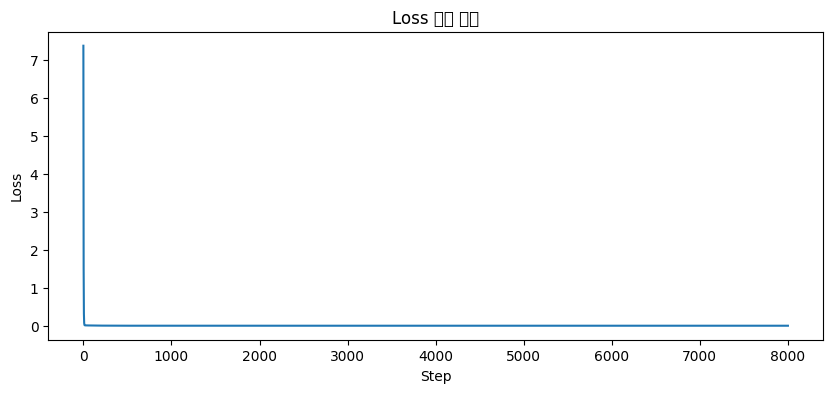

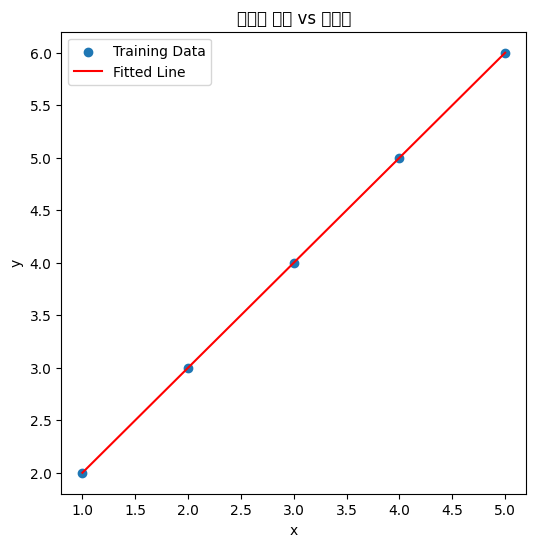

In [ ]:
import numpy as np

x_data = np.array([1,2,3,4,5]).reshape(5,1)
t_data = np.array([2,3,4,5,6]).reshape(5,1)

W = np.random.rand(1,1)
# 브로드 캐스팅으로 자동 형변환이 되기 때문에 편향은 1인 벡터 로 생성
b = np.random.rand(1)
print("W =", W, ", W.shape =", W.shape, ", b =", b, "b.shape =", b.shape)

def loss_func(x, t):
    # x와 w 의 모든 값이 행렬로 존재하고 그 값을 행렬곱 거기에 편향 b 를 더함 
    # y=W⋅x+b 에 W 와 x(x_data) 값이 행렬이기에 numpy의 dot 을 사용함
    y = np.dot(x, W) + b
    
    # 손실함수를 구하는 코드 t데이터에서 실제 y 데이터를 빼서 loss 값을 찾고 양수화 하기위해 제곱을 하고 모두 더한뒤 평균을 내기위해 행렬의 길이만큼 나누어줌
    return( np.sum( (t - y)**2 )) / (len(x))

# 수치미분 함수 -> 기울기를 구하는 함수
def numerical_derivative(f,x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        
        x[idx] = tmp_val + delta_x
        fx1 = f(x)
        
        x[idx] = tmp_val - delta_x
        fx2 = f(x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        x[idx] = tmp_val
        it.iternext()
        
    return(grad)
    
# 손실함수 계산 함수
# 입력변수 x, t : numpy type
def error_val(x, t):
    y = np.dot(x, W) + b
    
    return( np.sum( (t- y)**2 )) / (len(x))

# 학습을 마친 후, 임의의 데이터에 대해 미래 값 예측 함수
# 입력 변수 x : numpy type
def predict(x):
    y = np.dot(x, W) + b
    
    return y

learning_rate = 1e-2 # 발산하는 경우 1e-3 ~ 1e-6 등으로 바꿔서 실행

# 수치미분 함수에 x_data 와 t_data를 항상 넣기 위해, 즉 데이터를 고정하고 파라미터(W, b)만 바꾸기 위해 정의
# def f(x): loss_func(x_data, t_data) 임 즉 x 가 무엇이든 없든 loss_func를 출력하기 위한 람다 함수
f = lambda x : loss_func(x_data, t_data)

print("initial error value =", error_val(x_data, t_data), "initial W =", W, "\n", ",b =", b)

loss_history = [] # plt 시각화 용 행렬

for step in range(8001):
    
    #경사하강법
    # numerical_derivative 함수 즉 수치미분 함수에 f(손실함수 = loss_func)와 W 값을 넣으면 W에대한 손실의 미분한값( 죽 기울기)이 나옴
    # learning_rate 는 학습률 
    
    # θ = θ − η ⋅ ∇θ​L(θ) 의 계산 코드임 (경사하강법 공식 : 기울기의 반대방향으로 학습률 * 기울기만큼 이동)
    # 𝜃 : 파라미터 (W, b)           => W or b
    # 𝜂 : 학습률(learning rate)     => learning_rate
    # ∇𝜃𝐿(𝜃) : 손실 함수의 기울기    => numerical_derivative(f, W) 하면 나오는 값
    W -= learning_rate * numerical_derivative(f, W)
    b -= learning_rate * numerical_derivative(f, b)
    
    # 손실값 기록
    curr_loss = error_val(x_data, t_data)
    loss_history.append(curr_loss)
    
    if (step % 400 == 0):
        print("step =", step, "error value =",error_val(x_data, t_data), "W =", W, "b =", b)
        
        
# 시각화
import matplotlib.pyplot as plt

# -----------------------------
# 1. 손실값 그래프 그리기
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss 감소 과정")
plt.show()

# -----------------------------
# 2. 학습된 직선과 실제 데이터 비교
# -----------------------------
plt.figure(figsize=(6,6))
plt.scatter(x_data, t_data, label="Training Data")  # 실제 데이터 점
plt.plot(x_data, predict(x_data), color="red", label="Fitted Line")  # 학습된 직선
plt.xlabel("x")
plt.ylabel("y")
plt.title("학습된 직선 vs 데이터")
plt.legend()
plt.show()

In [25]:
predict(43)

array([[44.]])

## multi-variable regression - 경사 하강법

In [3]:
import numpy as np

#[1] 학습 데이터 준비
loaded_data = np.loadtxt('./data-01-test-score.csv', delimiter=',', dtype=np.float32)

x_data = loaded_data[ :, 0:-1]
t_data = loaded_data[ :, [-1]]

#[2] 임의의 직선 y = w1x1 + w2x2 + w3x3 + b 정의
W = np.random.rand(3,1)
b = np.random.rand(1)
print("W =", W, ", W.shape =", W.shape, ", b =", b, "b.shape =", b.shape)

#[3] 손실함수 정의
def loss_func(x, t):
    y = np.dot(x, W) + b
    
    return( np.sum( (t- y)**2 )) / (len(x))

#[4] 수치미분 함수 정의
def numerical_derivative(f,x):
    delta_x = 1e-4
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        
        x[idx] = tmp_val + delta_x
        fx1 = f(x)
        
        x[idx] = tmp_val - delta_x
        fx2 = f(x)
        
        grad[idx] = (fx1 - fx2) / (2*delta_x)
        
        x[idx] = tmp_val
        it.iternext()
        
    return(grad)
    
#[5] utility 함수 정의
def error_val(x, t):
    y = np.dot(x, W) + b
    
    return( np.sum( (t- y)**2 )) / (len(x))

def predict(x):
    y = np.dot(x, W) + b
    return y

#[6] 학습율 초기화 및 손심함수가 최소가 될 때까지 W, b  업데이트
learning_rate = 1e-5

f = lambda x : loss_func(x_data, t_data)

print("initial error value =", error_val(x_data, t_data), "initial W =", W, "\n", ",b =", b)


for step in range(10001):
    
    W -= learning_rate * numerical_derivative(f, W)
    b -= learning_rate * numerical_derivative(f, b)
    if (step % 400 == 0):
        print("step =", step, "error value =",error_val(x_data, t_data), "W =", W, "b =", b)

W = [[0.48172135]
 [0.38702946]
 [0.73635038]] , W.shape = (3, 1) , b = [0.5759154] b.shape = (1,)
initial error value = 1098.462625901824 initial W = [[0.48172135]
 [0.38702946]
 [0.73635038]] 
 ,b = [0.5759154]
step = 0 error value = 411.27206436780784 W = [[0.53441927]
 [0.44006103]
 [0.79073004]] b = [0.57631178]
step = 400 error value = 7.700210261354781 W = [[0.59100106]
 [0.51432756]
 [0.90739167]] b = [0.57644979]
step = 800 error value = 7.3667581826770006 W = [[0.56821248]
 [0.50845878]
 [0.93528018]] b = [0.57593499]
step = 1200 error value = 7.112294679150333 W = [[0.54766236]
 [0.50432809]
 [0.95929513]] b = [0.57538911]
step = 1600 error value = 6.916941622888792 W = [[0.52912624]
 [0.50157797]
 [0.98000397]] b = [0.57481644]
step = 2000 error value = 6.766088650870634 W = [[0.51240289]
 [0.49991622]
 [0.99788778]] b = [0.57422063]
step = 2400 error value = 6.648940026480989 W = [[0.49731178]
 [0.49910463]
 [1.01335473]] b = [0.57360481]
step = 2800 error value = 6.557474

In [4]:
test_data = np.array([100, 98, 81])

predict(test_data)

array([179.11489865])

# Logistic Regression

## classification